In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from utlis import cmplx as cmx
import numpy as np
from  utlis import trigon as tri
from utlis import basic as bsc

In [203]:
def butterfly(x_i, x_j, w_n_r):

    return cmx.add(x_i, cmx.mul(x_j, w_n_r)), cmx.add(x_i, -1 * cmx.mul(x_j, w_n_r))

def fft_ct(x__, sym = True):

    x_ = list_it(x__)

    if sym:
    
        x = pad2bin(x_)
    
    else:

        x = x_

    N = len(x)

    if N == 1 or type(x) in [int, float]:

        return x

    x_even, x_odd = eo_indices(x, both = True)

    EVEN = fft_ct(x_even)
    ODD = fft_ct(x_odd)

    X = x.copy()

    for k in range(int(N / 2)):
        
        t_ = cmx.mul(w_basis_N(k, N), ODD[k])
        x_i = cmx.add(EVEN[k], t_)
        x_j = cmx.add(EVEN[k], cmx.mul(-1, t_))

        X[k] = x_i
        X[k + int(N / 2)] = x_j

    return X

def w_basis_N(k, N):

    theta = (0, -2 * bsc.pi * k / N)

    return cmx.exp(theta)

def pad2bin(x_):

    x = x_.copy()
    N = len(x)

    if cmx.is_all_cmplx(x, assert_error = False):

        pad_elem = (0.0, 0.0)

    else:

        pad_elem = 0.0

    N_d = bsc.nearest_power_of(N, base = 2)

    if N != N_d:

        while len(x) != N_d:

            x.append(pad_elem)

    return x

def eo_indices(x, odds = True, both = False):

    N = len(x)

    if not both:

        c = 0

        if odds:

            c = 1

        return [x[2 * e + c] for e in range(int(N / 2))]
    
    else:

        return [x[2 * e] for e in range(int(N / 2))], [x[2 * e + 1] for e in range(int(N / 2))]
    
def list_it(x):

    if type(x) == list:

        return x

    x_list = []

    for x_ in x:

        x_list.append(float(x_))

    return x_list

In [190]:
def fft_it(x__, sym = True):

    x_ = list_it(x__)

    if sym:
    
        x = pad2bin(x_)
    
    else:

        x = x_

    N = len(x)

    x = bit_reverse(x)

    size = 2

    X = x.copy()

    while size <= N:

        half = int(size / 2)
        # angle_step = -2 * bsc.pi / size

        for k in range(half - 1):

            twiddle = w_basis_N(k, N = N) # potential BUG here!

            for n in range(k, N, size):

                t = cmx.mul(twiddle, x[n + half])
                u = x[n]

                x[n] = cmx.add(u, t)
                x[n + half] = cmx.add(u, cmx.mul(-1, t))

        size = size * 2

    return x

def bit_reverse(x):

    N = len(x)
    m, _ = bsc.base_analyzer(N, base = 2)

    for n in range(N):

        r = reverse_bits(n, m)

        if r > n:

            t_ = x[n]
            x[n] = x[r]
            x[r] = t_

    return x

def dec2bin_str(x, m = 8, reverse = False):

    bin_str = ''

    x_ = x

    while x_ >= 2:

        if bsc.is_even(x_):

            bin_str = bin_str + '0'

        else:

            bin_str = bin_str + '1'

        x_ = int(x_ / 2)

    if x == 0:

        bin_str = '0'

    elif x == 1:

        bin_str = '1'

    else:

        bin_str = bin_str + '1'

    while len(bin_str) < m:

        bin_str = bin_str + '0'

    if not reverse:

        bin_str = bin_str[::-1]

    return bin_str

def bin_str2dec(b, m = None):

    if m is None:

        m = len(b)

    res = 0

    for ib, b_ in enumerate(b):

        if int(b_) == 1:

            res = res + bsc.int_power(2, m - ib - 1)

    return res

def reverse_bits(n, m):

    return bin_str2dec(dec2bin_str(n, m = m, reverse = True))

In [185]:
from time import time

In [201]:
fs = 1024
t = np.linspace(0, 1, fs)

x_t = np.sin(2 * 100 * np.pi * t) + np.random.normal(0, scale = 0.1, size = t.shape)

start = time()
fft_sin = fft_ct(x_t, sym = True)
print(time() - start)

start = time()
npfft_sin = np.fft.fft(x_t)
print(time() - start)

start = time()
fft_sin_i = fft_it(x_t, sym = True)
print(time() - start)

4.925480127334595
0.0
0.9894111156463623


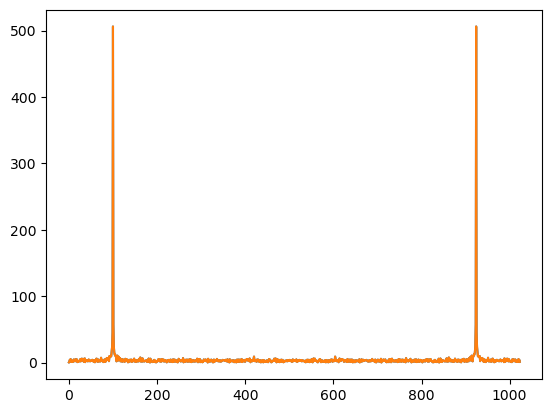

In [202]:
plt.plot(cmx.abs(fft_sin))
plt.plot(np.abs(npfft_sin))
# plt.plot(cmx.abs(fft_sin_i))

In [45]:
# basis = [0., 1., -0.1, -0.4, -0.5, 0.2, 0.45, -0.65]

basis = [(0., 0.1), (1., 0.), (-0.1, -0.2), (-0.4, 0.2), (-0.5, 0.), (0., 0.2), (0.45, -0.05), (0., -0.65)]

signal = []

for i in range(256):

    signal = signal + basis

In [52]:
fft_np = np.fft.fft(signal)

In [49]:
fft_s = fft_ct(signal)

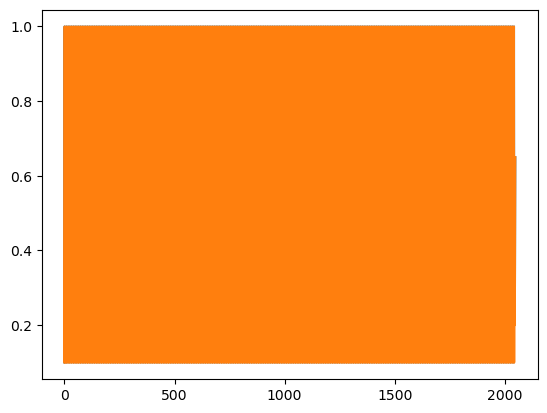

In [50]:
plt.plot(np.abs(fft_np))
# plt.plot(cmx.abs(fft_s))

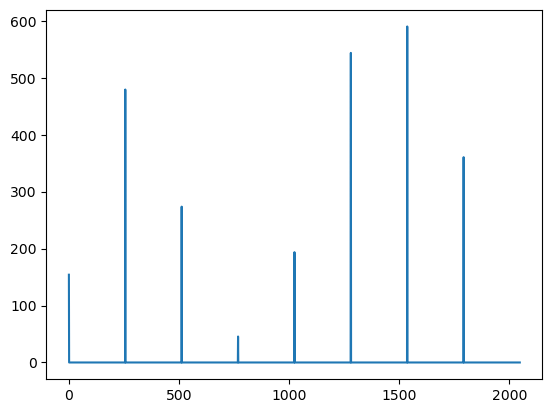

In [51]:
plt.plot(cmx.abs(fft_s))

In [10]:
a = 0.00023
print(bsc.ln_(a, precision=150))
print(np.log(a))

-8.377431249041079
-8.377431249041079
